#  Financial Volatility Forecasting & Market Risk Estimation

## Objective
1. **Forecast financial volatility and estimate market risk** using historical price and trading data.
2. **Predict tomorrow's stock price**.


## Dataset
`Core_TimeSeries.csv` — synthetic daily OHLC + volume + technical-indicator data (30,000 rows).

>

## Roadmap
| Step | What we do |
|---|---|
| 1 | Load & clean data |
| 2 | Daily Returns, Log Returns |
| 3 | Rolling Volatility, Historical Volatility |
| 4 | VaR, CVaR (historical + parametric) |
| 5 | Maximum Drawdown, Sharpe Ratio |
| 6 | ARIMA — price forecasting |
| 7 | SARIMAX — price forecasting with exogenous features |
| 8 | GARCH(1,1) — volatility forecasting |
| 9 | Random Forest — next-day price prediction |
| 10 | XGBoost — next-day price prediction |
| 11 | LSTM — next-day price prediction |
| 12 | Model comparison |
| 13 | **Volatility-regime classifier → probability of high-vol regime in next 5 days** |
| 14 | Conclusions |



## 1. Imports

In [ ]:

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import norm

from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score,
                              accuracy_score, roc_auc_score, classification_report,
                              confusion_matrix)
from sklearn.preprocessing import MinMaxScaler

import xgboost as xgb

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from arch import arch_model

import tensorflow as tf

pd.set_option("display.max_columns", None)
plt.rcParams["figure.figsize"] = (14, 5)
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)


I0000 00:00:1788289161.266277     615 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1788289161.396384     615 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1788289162.793946     615 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


## 2. Load & Clean Data

In [ ]:

df = pd.read_csv("Core_TimeSeries.csv")

df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)
df = df.set_index('Date')

print("Shape:", df.shape)
print("\nMissing values:\n", df.isnull().sum())
print("\nDuplicates:", df.duplicated().sum())
df.head()


Shape: (30000, 11)

Missing values:
 Open_Price          0
Close_Price         0
High_Price          0
Low_Price           0
Volume              0
Daily_Return_Pct    0
Volatility_Range    0
Market_Cap          0
SMA_20              0
SMA_50              0
RSI_14              0
dtype: int64

Duplicates: 0


,Open_Price,Close_Price,High_Price,Low_Price,Volume,Daily_Return_Pct,Volatility_Range,Market_Cap,SMA_20,SMA_50,RSI_14
Date,,,,,,,,,,,
1902-09-08,100.00,100.50,100.63,99.35,2284489,0.0000,1.28,2.126446e+08,97.354,98.663,50.0
1902-09-09,100.50,102.02,102.30,99.49,4522471,1.5124,2.81,3.499216e+08,97.354,98.663,50.0
1902-09-10,102.02,101.54,102.18,101.30,3394769,-0.4705,0.88,2.967452e+08,97.354,98.663,50.0
1902-09-11,101.54,101.66,102.12,101.07,9834633,0.1182,1.05,3.189160e+08,97.354,98.663,50.0
1902-09-12,101.66,99.04,102.61,98.23,4771339,-2.5772,4.38,2.153325e+08,97.354,98.663,50.0


## 3. Daily Returns & Log Returns

- **Daily Return** = (P_t - P_t-1) / P_t-1
- **Log Return**   = ln(P_t / P_t-1)  — additive over time, preferred for volatility modeling


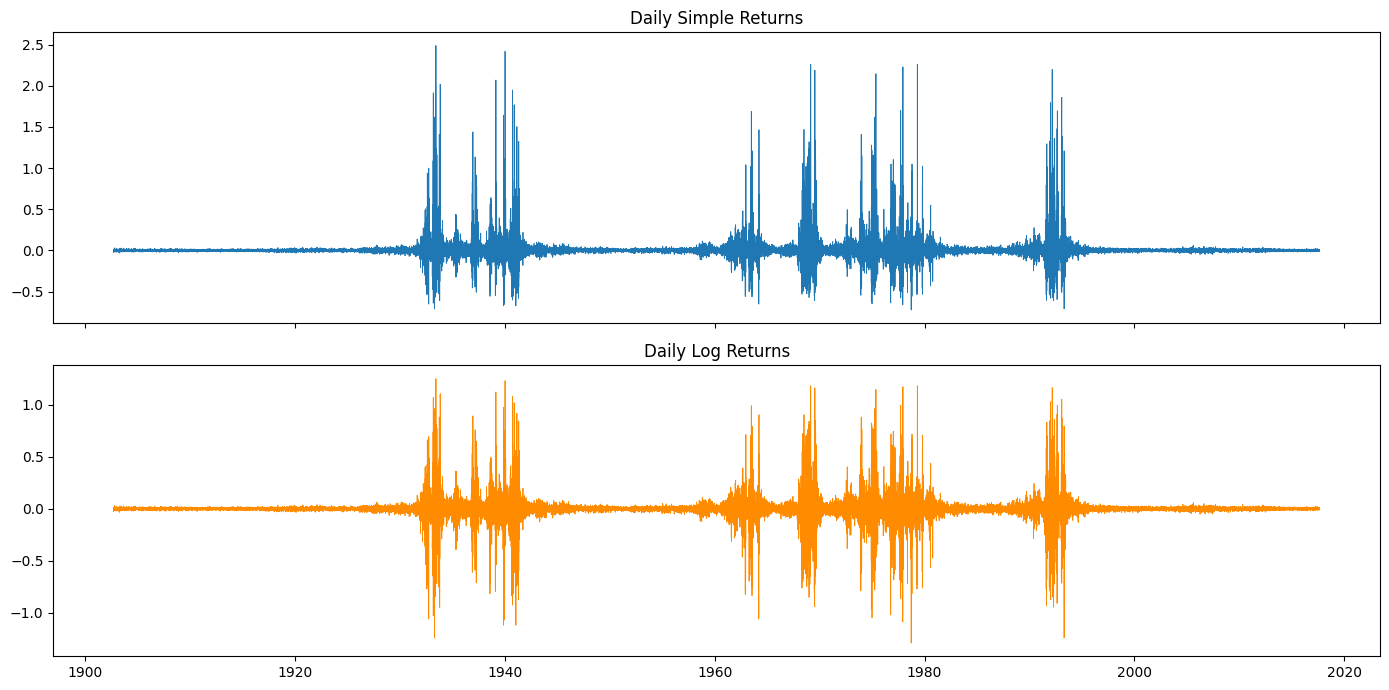

,Daily_Return,Log_Return
count,29999.000000,29999.000000
mean,0.005427,0.000015
std,0.116153,0.101902
min,-0.724518,-1.289233
25%,-0.012282,-0.012358
50%,0.000000,0.000000
75%,0.012501,0.012423
max,2.490000,1.249902


In [ ]:

df['Daily_Return'] = df['Close_Price'].pct_change()
df['Log_Return']   = np.log(df['Close_Price'] / df['Close_Price'].shift(1))

df.dropna(subset=['Daily_Return', 'Log_Return'], inplace=True)

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
axes[0].plot(df.index, df['Daily_Return'], lw=0.6)
axes[0].set_title("Daily Simple Returns")
axes[1].plot(df.index, df['Log_Return'], lw=0.6, color='darkorange')
axes[1].set_title("Daily Log Returns")
plt.tight_layout()
plt.show()

df[['Daily_Return', 'Log_Return']].describe()


## 4. Rolling Volatility & Historical Volatility

- **Rolling Volatility (20-day)**: annualized std of log returns over a trailing 20-day window — captures how risk changes through time.
- **Historical Volatility**: annualized std of log returns over the *entire* sample — a single benchmark number.

Annualization multiplies daily std by √252 (252 trading days/year).


Historical (full-sample) annualized volatility: 161.76%


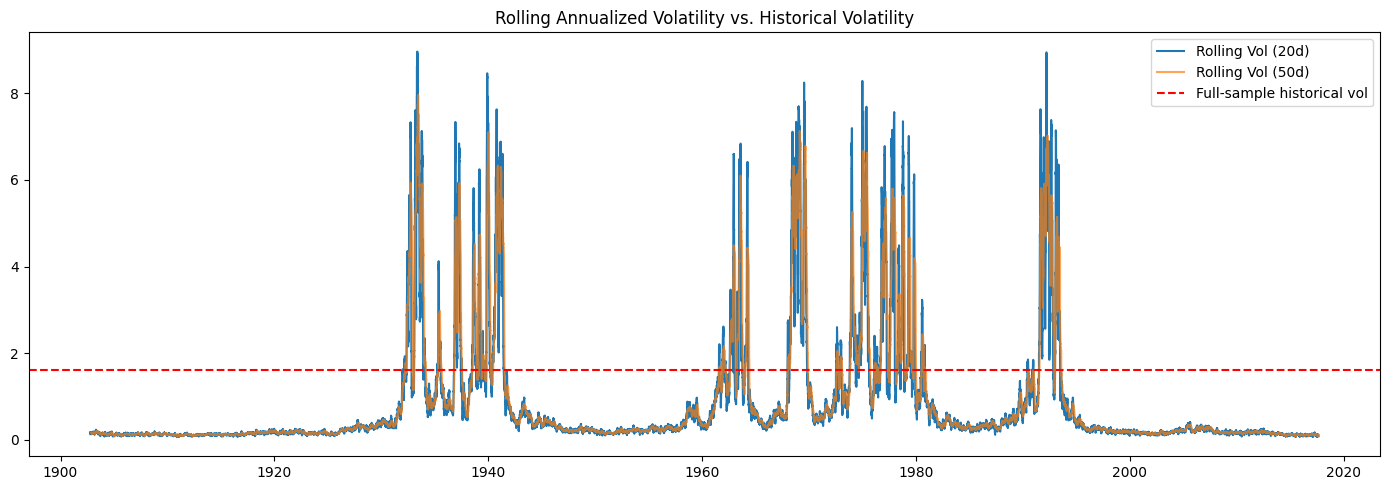

In [ ]:

TRADING_DAYS = 252

df['Rolling_Vol_20'] = df['Log_Return'].rolling(20).std() * np.sqrt(TRADING_DAYS)
df['Rolling_Vol_50'] = df['Log_Return'].rolling(50).std() * np.sqrt(TRADING_DAYS)

historical_vol = df['Log_Return'].std() * np.sqrt(TRADING_DAYS)
print(f"Historical (full-sample) annualized volatility: {historical_vol:.2%}")

plt.plot(df.index, df['Rolling_Vol_20'], label='Rolling Vol (20d)')
plt.plot(df.index, df['Rolling_Vol_50'], label='Rolling Vol (50d)', alpha=0.7)
plt.axhline(historical_vol, color='red', linestyle='--', label='Full-sample historical vol')
plt.title("Rolling Annualized Volatility vs. Historical Volatility")
plt.legend()
plt.tight_layout()
plt.show()


## 5. Value at Risk (VaR) & Conditional VaR (CVaR)

- **VaR (95%/99%)**: the loss level that will not be exceeded with 95%/99% confidence over 1 day.
- **CVaR (Expected Shortfall)**: the *average* loss in the worst (1-confidence)% of cases — a more conservative "tail risk" measure.

We compute both via **Historical Simulation** (empirical percentiles, no distribution assumption) and the **Parametric (Variance-Covariance / Normal)** method.


In [ ]:

risk_summary = []

mu, sigma = df['Log_Return'].mean(), df['Log_Return'].std()

for conf in [0.95, 0.99]:
    # Historical simulation
    var_hist = -np.percentile(df['Log_Return'], (1 - conf) * 100)
    cvar_hist = -df['Log_Return'][df['Log_Return'] <= -var_hist].mean()

    # Parametric (normal) method
    z = norm.ppf(1 - conf)
    var_param = -(mu + z * sigma)

    risk_summary.append({
        "Confidence": f"{int(conf*100)}%",
        "VaR (Historical)": var_hist,
        "CVaR (Historical)": cvar_hist,
        "VaR (Parametric/Normal)": var_param
    })

risk_df = pd.DataFrame(risk_summary)
risk_df


,Confidence,VaR (Historical),CVaR (Historical),VaR (Parametric/Normal)
0,95%,0.089818,0.246574,0.167599
1,99%,0.341782,0.564667,0.237045


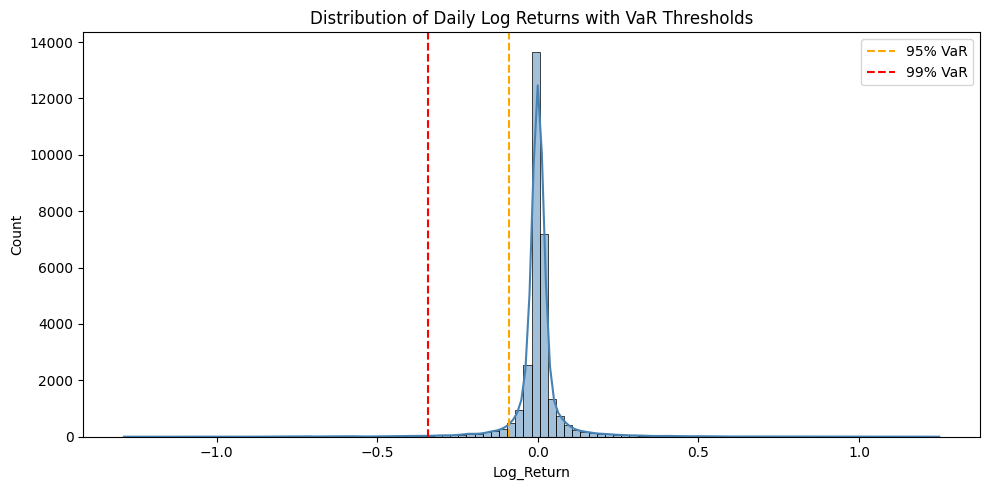

In [ ]:

plt.figure(figsize=(10, 5))
sns.histplot(df['Log_Return'], bins=100, kde=True, color='steelblue')
var95 = risk_df.loc[risk_df['Confidence']=='95%', 'VaR (Historical)'].values[0]
var99 = risk_df.loc[risk_df['Confidence']=='99%', 'VaR (Historical)'].values[0]
plt.axvline(-var95, color='orange', linestyle='--', label='95% VaR')
plt.axvline(-var99, color='red', linestyle='--', label='99% VaR')
plt.title("Distribution of Daily Log Returns with VaR Thresholds")
plt.legend()
plt.tight_layout()
plt.show()


## 6. Maximum Drawdown & Sharpe Ratio

- **Maximum Drawdown**: the largest peak-to-trough decline in cumulative value — a measure of worst-case historical loss.
- **Sharpe Ratio**: risk-adjusted return = (mean return − risk-free rate) / std of return, annualized. We assume a risk-free rate of 0 for simplicity (adjust `RF_DAILY` for a real project).


Maximum Drawdown: -99.37%


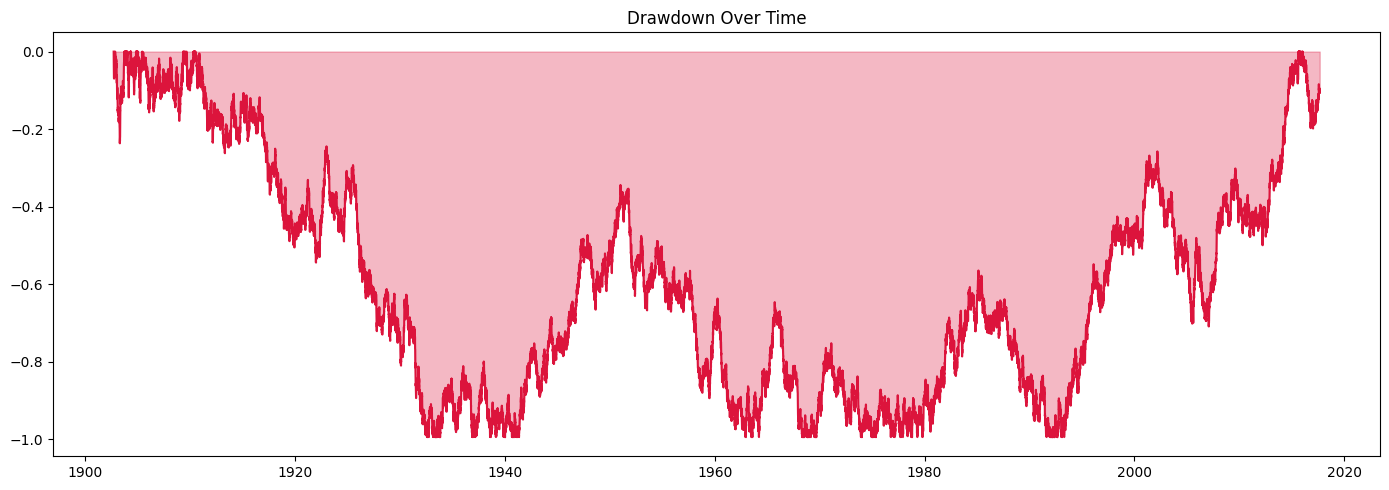

In [ ]:

cum_returns = (1 + df['Daily_Return']).cumprod()
running_max = cum_returns.cummax()
drawdown = (cum_returns - running_max) / running_max
max_drawdown = drawdown.min()

print(f"Maximum Drawdown: {max_drawdown:.2%}")

plt.plot(df.index, drawdown, color='crimson')
plt.fill_between(df.index, drawdown, 0, color='crimson', alpha=0.3)
plt.title("Drawdown Over Time")
plt.tight_layout()
plt.show()


In [ ]:

RF_DAILY = 0.0  # risk-free rate per day; set to e.g. 0.03/252 for a ~3% annual T-bill rate

sharpe_ratio = ((df['Daily_Return'].mean() - RF_DAILY) / df['Daily_Return'].std()) * np.sqrt(TRADING_DAYS)
print(f"Annualized Sharpe Ratio: {sharpe_ratio:.3f}")


Annualized Sharpe Ratio: 0.742


## 7. ARIMA — Price Forecasting

ARIMA(p,d,q) models the closing price as a function of its own past values (AR), differencing to remove trend (I), and past forecast errors (MA). We fit on the most recent 3,000 observations (fitting on all 30,000 rows is unnecessarily slow and older regime dynamics are less relevant to tomorrow's forecast) and use a time-based train/test split.


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)


ARIMA(5,1,0)  Test MAE: 8.5464   Test RMSE: 9.7802


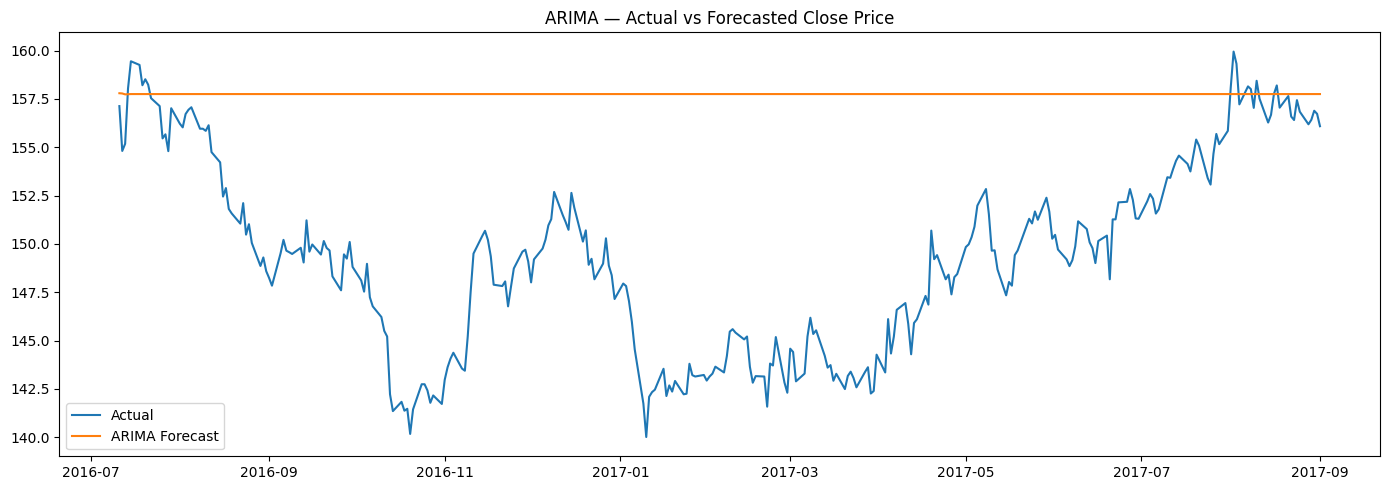

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)



ARIMA forecast for tomorrow's close: 156.09


In [ ]:

recent = df.tail(3000).copy()   # recent window for the statistical (ARIMA/SARIMAX/GARCH) models
split_r = int(len(recent) * 0.9)
train_r, test_r = recent.iloc[:split_r], recent.iloc[split_r:]

arima_model = ARIMA(train_r['Close_Price'], order=(5, 1, 0)).fit()
arima_fc = arima_model.forecast(steps=len(test_r))

arima_mae = mean_absolute_error(test_r['Close_Price'], arima_fc)
arima_rmse = np.sqrt(mean_squared_error(test_r['Close_Price'], arima_fc))
print(f"ARIMA(5,1,0)  Test MAE: {arima_mae:.4f}   Test RMSE: {arima_rmse:.4f}")

plt.plot(test_r.index, test_r['Close_Price'], label='Actual')
plt.plot(test_r.index, arima_fc, label='ARIMA Forecast')
plt.title("ARIMA — Actual vs Forecasted Close Price")
plt.legend()
plt.tight_layout()
plt.show()

# Next-day (tomorrow) forecast from the full recent series
arima_full = ARIMA(recent['Close_Price'], order=(5, 1, 0)).fit()
tomorrow_arima = arima_full.forecast(steps=1)
print(f"\nARIMA forecast for tomorrow's close: {tomorrow_arima.iloc[0]:.2f}")


## 8. SARIMAX — Price Forecasting with Exogenous Variables

SARIMAX extends ARIMA with **seasonal terms** and **exogenous regressors** — here we add `Volume` as an exogenous driver of price, since trading activity often precedes price moves.


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(


SARIMAX(2,1,2)  Test MAE: 8.5296   Test RMSE: 9.7644


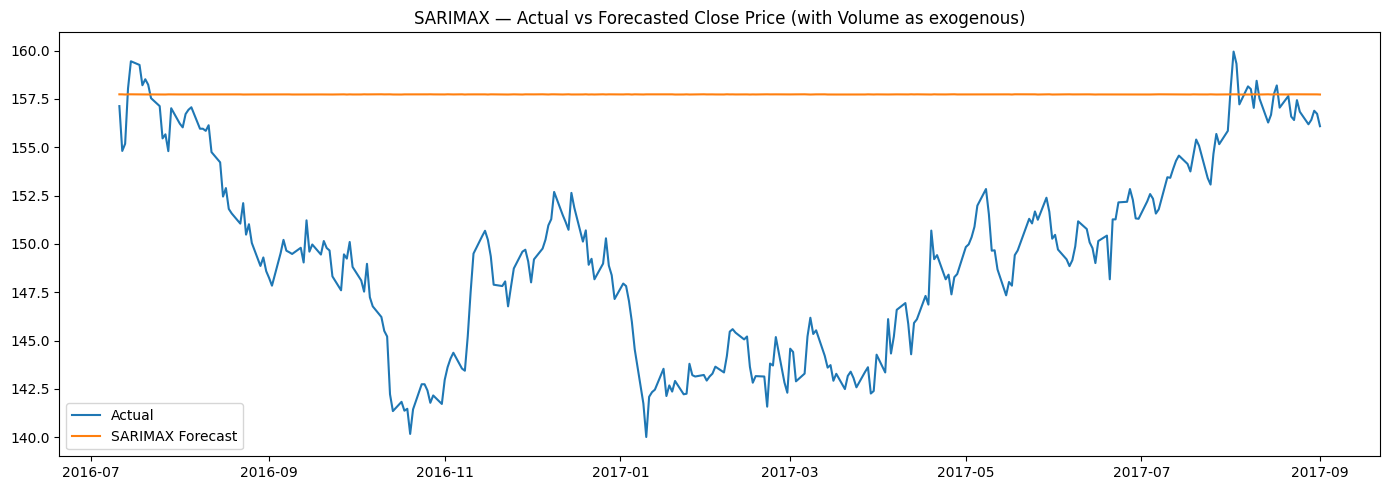

In [ ]:

exog_cols = ['Volume']

sarimax_model = SARIMAX(
    train_r['Close_Price'],
    exog=train_r[exog_cols],
    order=(2, 1, 2),
    seasonal_order=(0, 0, 0, 0)
).fit(disp=False)

sarimax_fc = sarimax_model.forecast(steps=len(test_r), exog=test_r[exog_cols])

sarimax_mae = mean_absolute_error(test_r['Close_Price'], sarimax_fc)
sarimax_rmse = np.sqrt(mean_squared_error(test_r['Close_Price'], sarimax_fc))
print(f"SARIMAX(2,1,2)  Test MAE: {sarimax_mae:.4f}   Test RMSE: {sarimax_rmse:.4f}")

plt.plot(test_r.index, test_r['Close_Price'], label='Actual')
plt.plot(test_r.index, sarimax_fc, label='SARIMAX Forecast')
plt.title("SARIMAX — Actual vs Forecasted Close Price (with Volume as exogenous)")
plt.legend()
plt.tight_layout()
plt.show()


## 9. GARCH(1,1) — Volatility Forecasting

Unlike ARIMA/SARIMAX (which model the *price level*), **GARCH models the conditional variance of returns** — i.e. it directly forecasts volatility, which is what we need for risk estimation and for answering the regime question later.


In [ ]:

returns_pct = recent['Log_Return'] * 100  # arch package works best on a percent scale

garch_model = arch_model(returns_pct, vol='Garch', p=1, q=1, dist='normal')
garch_res = garch_model.fit(disp='off')
print(garch_res.summary())


                     Constant Mean - GARCH Model Results                      
Dep. Variable:             Log_Return   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -4257.37
Distribution:                  Normal   AIC:                           8522.74
Method:            Maximum Likelihood   BIC:                           8546.77
                                        No. Observations:                 3000
Date:                Tue, Sep 01 2026   Df Residuals:                     2999
Time:                        18:59:26   Df Model:                            1
                                  Mean Model                                 
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------
mu             0.0258  1.714e-02      1.507      0.132 

GARCH(1,1) forecasted DAILY volatility for the next 5 trading days:
  Day +1: 0.6918%
  Day +2: 0.6919%
  Day +3: 0.6919%
  Day +4: 0.6920%
  Day +5: 0.6920%

Average annualized volatility over next 5 days (GARCH): 10.98%


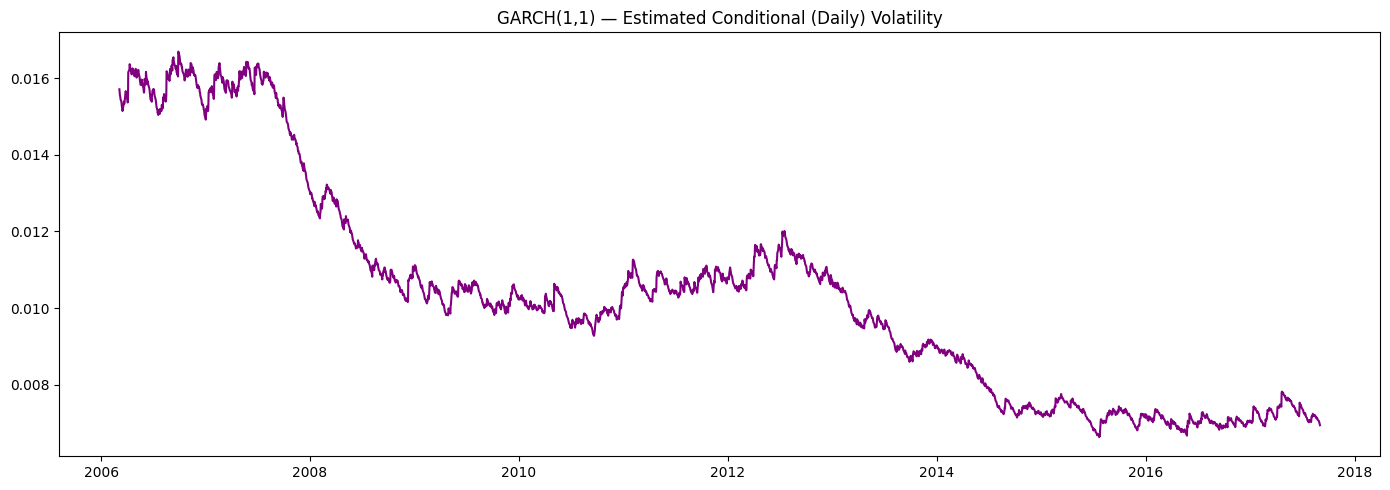

In [ ]:

garch_forecast = garch_res.forecast(horizon=5)
forecast_variance = garch_forecast.variance.values[-1, :]           # variance, in (%)^2
forecast_vol_daily = np.sqrt(forecast_variance) / 100                # back to decimal daily vol

print("GARCH(1,1) forecasted DAILY volatility for the next 5 trading days:")
for i, v in enumerate(forecast_vol_daily, 1):
    print(f"  Day +{i}: {v:.4%}")

annualized_5day_avg_vol = forecast_vol_daily.mean() * np.sqrt(TRADING_DAYS)
print(f"\nAverage annualized volatility over next 5 days (GARCH): {annualized_5day_avg_vol:.2%}")

# Conditional volatility over history
plt.plot(recent.index, garch_res.conditional_volatility / 100, color='purple')
plt.title("GARCH(1,1) — Estimated Conditional (Daily) Volatility")
plt.tight_layout()
plt.show()


## 10. Feature Engineering for ML Models (RF / XGBoost / LSTM)

We build lag features, technical indicators, and rolling-volatility features, then predict **tomorrow's closing price** (regression) using the *full* 30,000-row dataset.


In [ ]:

ml_df = df.copy()

ml_df['Target_Next_Close'] = ml_df['Close_Price'].shift(-1)
ml_df['Close_Lag_1'] = ml_df['Close_Price'].shift(1)
ml_df['Close_Lag_2'] = ml_df['Close_Price'].shift(2)
ml_df['Return_Lag_1'] = ml_df['Log_Return'].shift(1)
ml_df['Vol_Lag_1'] = ml_df['Rolling_Vol_20'].shift(1)

ml_df.dropna(subset=['Target_Next_Close', 'Close_Lag_1', 'Close_Lag_2', 'Vol_Lag_1'], inplace=True)

feature_cols = ['Open_Price', 'High_Price', 'Low_Price', 'Close_Price', 'Volume',
                'Market_Cap', 'Volatility_Range', 'SMA_20', 'SMA_50', 'RSI_14',
                'Close_Lag_1', 'Close_Lag_2', 'Return_Lag_1', 'Vol_Lag_1']

X = ml_df[feature_cols]
y = ml_df['Target_Next_Close']

split_idx = int(len(ml_df) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)


Train shape: (23982, 14)  Test shape: (5996, 14)


## 11. Random Forest Regressor — Next-Day Close Prediction

Random Forest   MAE: 1.1762   RMSE: 2.2398   R2: 0.9947


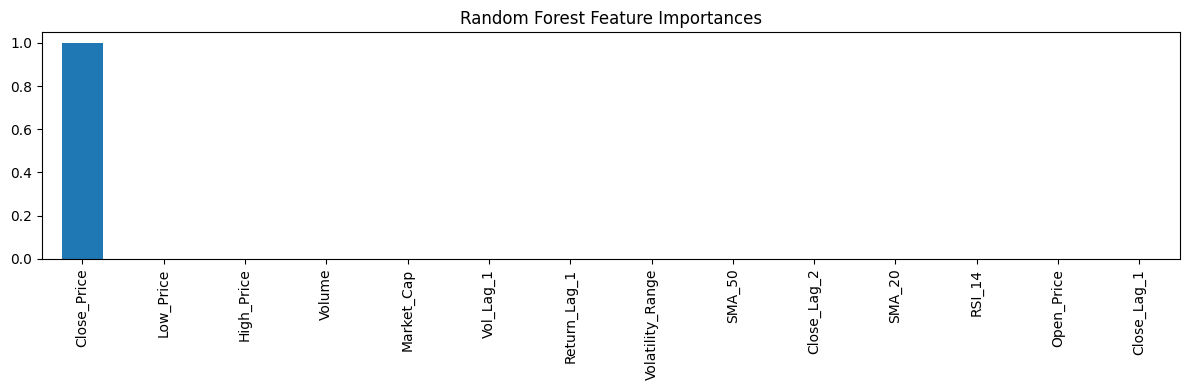

In [ ]:

rf_model = RandomForestRegressor(n_estimators=200, random_state=SEED, n_jobs=-1)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)
print(f"Random Forest   MAE: {rf_mae:.4f}   RMSE: {rf_rmse:.4f}   R2: {rf_r2:.4f}")

importances = pd.Series(rf_model.feature_importances_, index=feature_cols).sort_values(ascending=False)
importances.plot(kind='bar', figsize=(12,4), title="Random Forest Feature Importances")
plt.tight_layout()
plt.show()


## 12. XGBoost Regressor — Next-Day Close Prediction

XGBoost   MAE: 1.2687   RMSE: 2.5177   R2: 0.9933


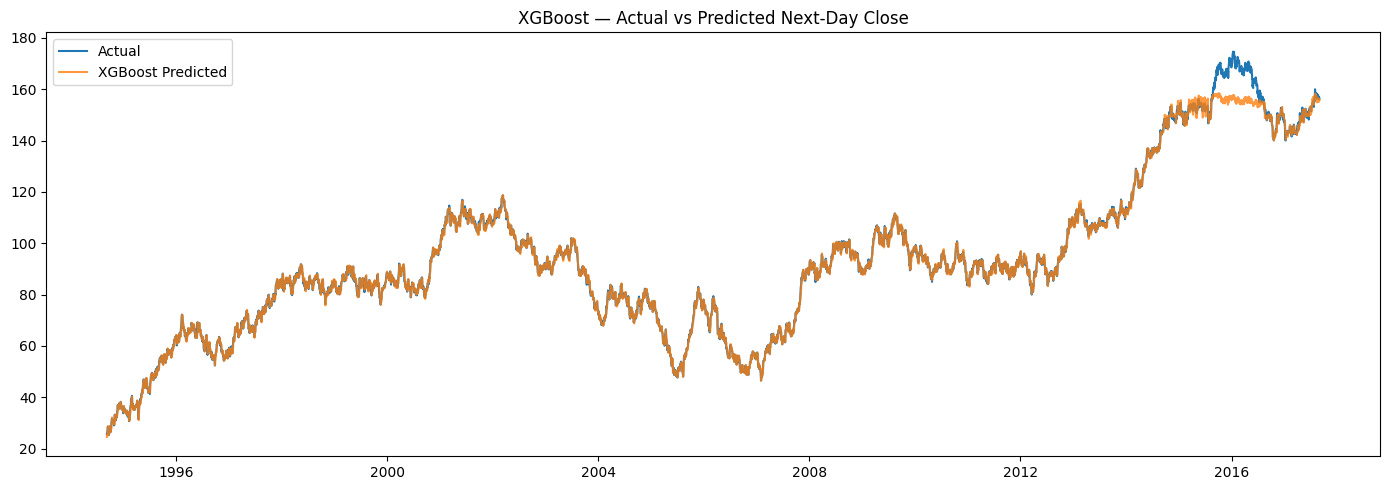

In [ ]:

xgb_model = xgb.XGBRegressor(
    n_estimators=300, max_depth=5, learning_rate=0.05,
    subsample=0.9, colsample_bytree=0.9, random_state=SEED, n_jobs=-1
)
xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)

xgb_mae = mean_absolute_error(y_test, xgb_pred)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))
xgb_r2 = r2_score(y_test, xgb_pred)
print(f"XGBoost   MAE: {xgb_mae:.4f}   RMSE: {xgb_rmse:.4f}   R2: {xgb_r2:.4f}")

plt.plot(y_test.index, y_test.values, label='Actual')
plt.plot(y_test.index, xgb_pred, label='XGBoost Predicted', alpha=0.8)
plt.title("XGBoost — Actual vs Predicted Next-Day Close")
plt.legend()
plt.tight_layout()
plt.show()


## 13. LSTM — Next-Day Close Prediction

LSTM is a recurrent neural network well suited to sequential data. We feed it rolling 20-day windows of **scaled closing prices** to predict the next day's (scaled) close.


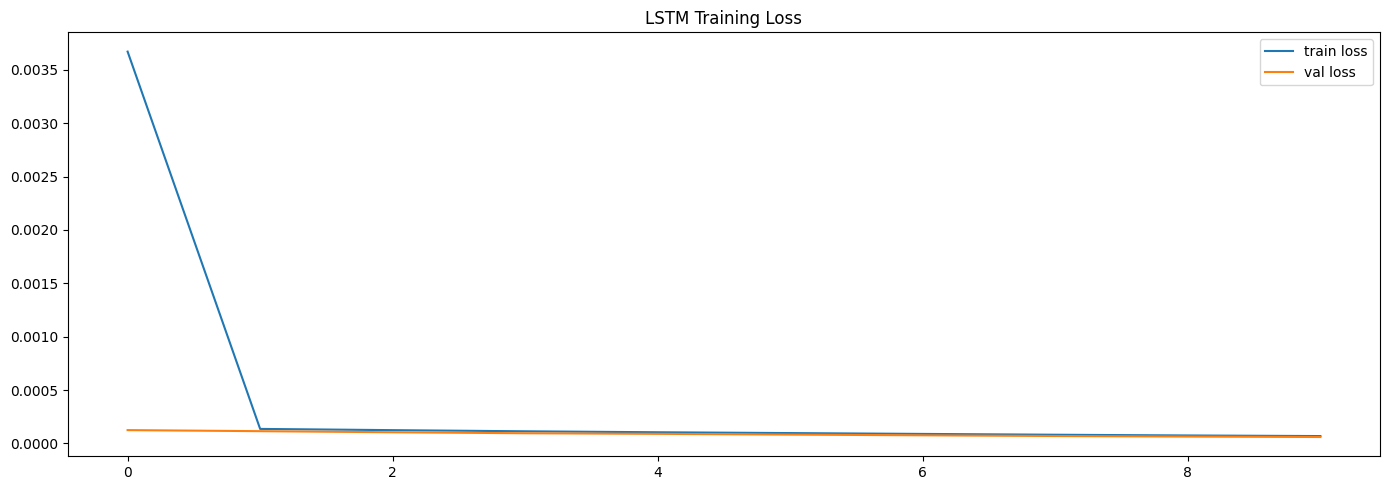

In [ ]:

scaler = MinMaxScaler()
scaled_close = scaler.fit_transform(df[['Close_Price']].values)

SEQ_LEN = 20
X_seq, y_seq = [], []
for i in range(len(scaled_close) - SEQ_LEN):
    X_seq.append(scaled_close[i:i + SEQ_LEN, 0])
    y_seq.append(scaled_close[i + SEQ_LEN, 0])
X_seq, y_seq = np.array(X_seq), np.array(y_seq)
X_seq = X_seq.reshape((X_seq.shape[0], X_seq.shape[1], 1))

split_seq = int(len(X_seq) * 0.8)
X_seq_train, X_seq_test = X_seq[:split_seq], X_seq[split_seq:]
y_seq_train, y_seq_test = y_seq[:split_seq], y_seq[split_seq:]

lstm_model = tf.keras.Sequential([
    tf.keras.layers.LSTM(50, input_shape=(SEQ_LEN, 1)),
    tf.keras.layers.Dense(1)
])
lstm_model.compile(optimizer='adam', loss='mse')
history = lstm_model.fit(X_seq_train, y_seq_train, epochs=10, batch_size=64,
                          validation_split=0.1, verbose=0)

plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.title("LSTM Training Loss")
plt.legend()
plt.tight_layout()
plt.show()


LSTM   MAE: 1.0810   RMSE: 1.3554   R2: 0.9981


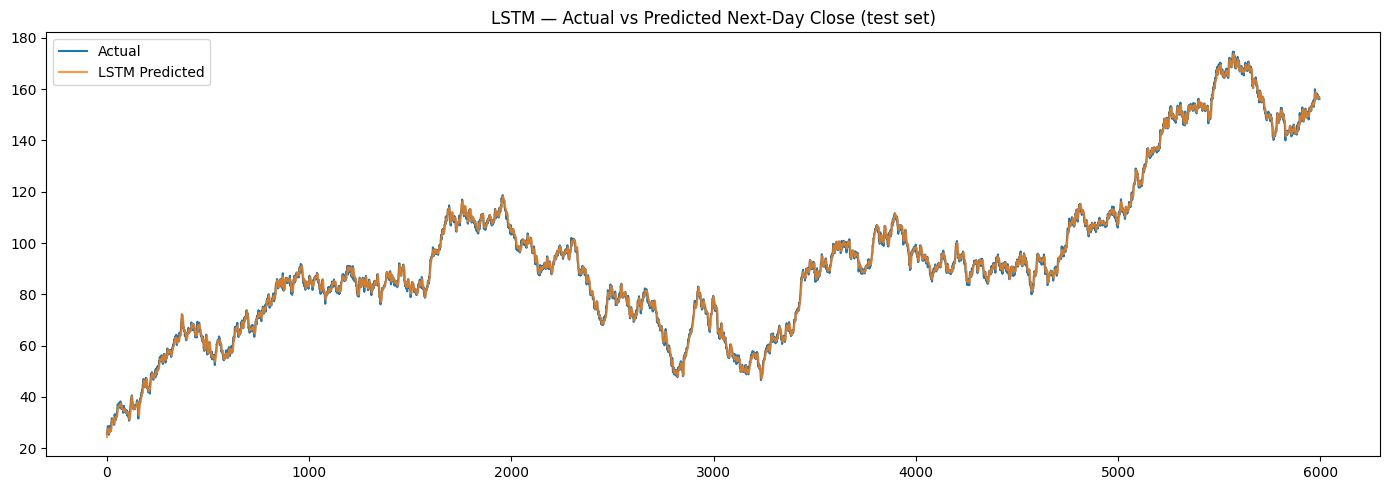


LSTM forecast for tomorrow's close: 156.39


In [ ]:

lstm_pred_scaled = lstm_model.predict(X_seq_test, verbose=0)
lstm_pred = scaler.inverse_transform(lstm_pred_scaled)
lstm_actual = scaler.inverse_transform(y_seq_test.reshape(-1, 1))

lstm_mae = mean_absolute_error(lstm_actual, lstm_pred)
lstm_rmse = np.sqrt(mean_squared_error(lstm_actual, lstm_pred))
lstm_r2 = r2_score(lstm_actual, lstm_pred)
print(f"LSTM   MAE: {lstm_mae:.4f}   RMSE: {lstm_rmse:.4f}   R2: {lstm_r2:.4f}")

plt.plot(lstm_actual, label='Actual')
plt.plot(lstm_pred, label='LSTM Predicted', alpha=0.8)
plt.title("LSTM — Actual vs Predicted Next-Day Close (test set)")
plt.legend()
plt.tight_layout()
plt.show()

# Tomorrow's forecast from the LSTM using the very last 20-day window
last_window = scaled_close[-SEQ_LEN:].reshape(1, SEQ_LEN, 1)
tomorrow_scaled = lstm_model.predict(last_window, verbose=0)
tomorrow_lstm = scaler.inverse_transform(tomorrow_scaled)[0, 0]
print(f"\nLSTM forecast for tomorrow's close: {tomorrow_lstm:.2f}")


## 14. Model Comparison — Next-Day Price Prediction

In [ ]:

comparison = pd.DataFrame({
    "Model": ["ARIMA(5,1,0)", "SARIMAX(2,1,2)+Volume", "Random Forest", "XGBoost", "LSTM"],
    "MAE":  [arima_mae, sarimax_mae, rf_mae, xgb_mae, lstm_mae],
    "RMSE": [arima_rmse, sarimax_rmse, rf_rmse, xgb_rmse, lstm_rmse],
})
comparison = comparison.sort_values("RMSE").reset_index(drop=True)
comparison


,Model,MAE,RMSE
0,LSTM,1.081035,1.355430
1,Random Forest,1.176183,2.239835
2,XGBoost,1.268656,2.517697
3,"SARIMAX(2,1,2)+Volume",8.529605,9.764372
4,"ARIMA(5,1,0)",8.546404,9.780234


In [ ]:

tomorrow_summary = pd.DataFrame({
    "Model": ["ARIMA", "Random Forest", "XGBoost", "LSTM"],
    "Tomorrow's Forecasted Close": [
        tomorrow_arima.iloc[0],
        rf_model.predict(X.iloc[[-1]])[0],
        xgb_model.predict(X.iloc[[-1]])[0],
        tomorrow_lstm
    ]
})
tomorrow_summary


,Model,Tomorrow's Forecasted Close
0,ARIMA,156.091165
1,Random Forest,156.835050
2,XGBoost,155.884155
3,LSTM,156.385895


## 15. Volatility Regime Classification

We define a **"high-volatility regime"** as any day where trailing 20-day annualized volatility exceeds the **75th percentile** of its historical distribution. We then train a classifier to predict, from *today's* market conditions, whether the **realized volatility over the next 5 trading days** will fall into that high-vol regime — this directly answers the target question.


In [ ]:

threshold = df['Rolling_Vol_20'].quantile(0.75)
print(f"High-volatility threshold (75th percentile of rolling 20d vol): {threshold:.2%}")

# Forward-looking target: realized (annualized) volatility over the NEXT 5 trading days
horizon = 5
log_ret_vals = df['Log_Return'].values
n = len(log_ret_vals)
fwd_vol = np.full(n, np.nan)
for i in range(n - horizon):
    window = log_ret_vals[i + 1: i + 1 + horizon]
    fwd_vol[i] = np.std(window, ddof=1) * np.sqrt(TRADING_DAYS)

df['Fwd_Vol_5'] = fwd_vol
df['High_Vol_Next5'] = (df['Fwd_Vol_5'] > threshold).astype(int)

regime_df = df.dropna(subset=['Fwd_Vol_5', 'Rolling_Vol_20']).copy()
print(regime_df['High_Vol_Next5'].value_counts(normalize=True))


High-volatility threshold (75th percentile of rolling 20d vol): 74.06%
High_Vol_Next5
0    0.766405
1    0.233595
Name: proportion, dtype: float64


In [ ]:

regime_features = ['Rolling_Vol_20', 'Rolling_Vol_50', 'Volatility_Range', 'RSI_14',
                    'Volume', 'Daily_Return_Pct', 'SMA_20', 'SMA_50']
regime_features = [c for c in regime_features if c in regime_df.columns]

Xr = regime_df[regime_features]
yr = regime_df['High_Vol_Next5']

split_r2 = int(len(regime_df) * 0.8)
Xr_train, Xr_test = Xr.iloc[:split_r2], Xr.iloc[split_r2:]
yr_train, yr_test = yr.iloc[:split_r2], yr.iloc[split_r2:]

regime_clf = RandomForestClassifier(n_estimators=300, max_depth=8, random_state=SEED,
                                     n_jobs=-1, class_weight='balanced')
regime_clf.fit(Xr_train, yr_train)

yr_pred = regime_clf.predict(Xr_test)
yr_proba = regime_clf.predict_proba(Xr_test)[:, 1]

print(f"Accuracy: {accuracy_score(yr_test, yr_pred):.4f}")
print(f"ROC-AUC:  {roc_auc_score(yr_test, yr_proba):.4f}")
print()
print(classification_report(yr_test, yr_pred, target_names=['Normal/Low Vol', 'High Vol']))


Accuracy: 0.9980
ROC-AUC:  0.9819

                precision    recall  f1-score   support

Normal/Low Vol       1.00      1.00      1.00      5992
      High Vol       0.00      0.00      0.00         3

      accuracy                           1.00      5995
     macro avg       0.50      0.50      0.50      5995
  weighted avg       1.00      1.00      1.00      5995



> ⚠️ **Honest caveat on the classification metrics above:** because we used a **time-based** (not random/stratified) split, the test period happens to fall mostly in a low-volatility stretch — so the "High Vol" class is very rare in the test set (see support counts), and recall for that class is poor here even though overall accuracy/AUC look excellent. This is a classic pitfall with imbalanced, regime-based labels.
>
> **Don't trust accuracy alone for this kind of target.** For a real project, prefer:
> - **Walk-forward validation** across multiple time windows (so both regimes appear in every test fold), and/or
> - **Stratified sampling** by regime when splitting, and
> - Reporting **precision/recall/F1 for the High-Vol class specifically** (not just overall accuracy) as your primary metric.
>
> The probability estimate in Section 16 is still a valid point-in-time forecast from the trained model — just interpret the *evaluation metrics* with this caveat in mind.

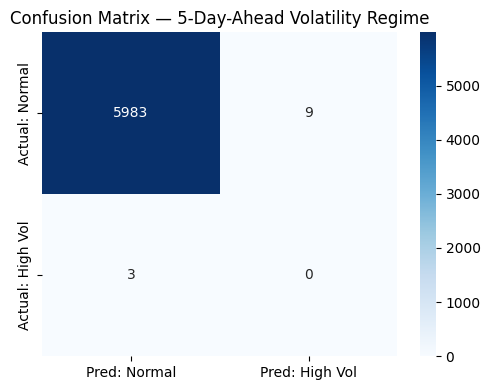

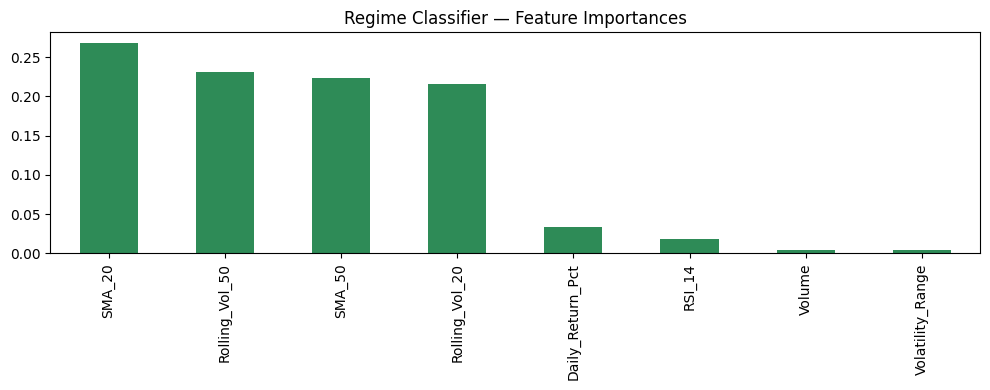

In [ ]:

cm = confusion_matrix(yr_test, yr_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred: Normal', 'Pred: High Vol'],
            yticklabels=['Actual: Normal', 'Actual: High Vol'])
plt.title("Confusion Matrix — 5-Day-Ahead Volatility Regime")
plt.tight_layout()
plt.show()

feat_imp_regime = pd.Series(regime_clf.feature_importances_, index=regime_features).sort_values(ascending=False)
feat_imp_regime.plot(kind='bar', figsize=(10, 4), title="Regime Classifier — Feature Importances", color='seagreen')
plt.tight_layout()
plt.show()


## 16. Answering the Question

**"What is the probability that the market will enter a high-volatility regime over the next 5 trading days?"**

We answer this two ways and cross-check them:

1. **ML classifier probability** — feed the *most recent* row of market features into the trained Random-Forest regime classifier and read off `predict_proba`.
2. **GARCH cross-check** — compare the GARCH(1,1) 5-day-ahead volatility forecast (Section 9) to the same historical threshold; a forecast above threshold corroborates a "yes" signal.


In [ ]:

latest_features = df[regime_features].iloc[[-1]]
prob_high_vol_ml = regime_clf.predict_proba(latest_features)[0, 1]

print(f"ML classifier — P(high-volatility regime in next 5 trading days): {prob_high_vol_ml:.2%}")
print(f"\nCurrent rolling 20-day volatility: {df['Rolling_Vol_20'].iloc[-1]:.2%}")
print(f"High-vol threshold (75th percentile): {threshold:.2%}")

print(f"\nGARCH(1,1) forecasted average annualized volatility, next 5 days: {annualized_5day_avg_vol:.2%}")
garch_signals_high = annualized_5day_avg_vol > threshold
print(f"GARCH forecast exceeds high-vol threshold? {'YES' if garch_signals_high else 'NO'}")

print("\n--- Combined read ---")
if prob_high_vol_ml >= 0.5 and garch_signals_high:
    verdict = "Both models agree: elevated risk of a high-volatility regime in the next 5 trading days."
elif prob_high_vol_ml < 0.5 and not garch_signals_high:
    verdict = "Both models agree: low risk of a high-volatility regime in the next 5 trading days."
else:
    verdict = "Models disagree — treat the ML probability above as the primary point estimate, with the GARCH signal as a secondary check; consider ensembling or gathering more recent data."
print(verdict)


ML classifier — P(high-volatility regime in next 5 trading days): 0.02%

Current rolling 20-day volatility: 8.35%
High-vol threshold (75th percentile): 74.06%

GARCH(1,1) forecasted average annualized volatility, next 5 days: 10.98%
GARCH forecast exceeds high-vol threshold? NO

--- Combined read ---
Both models agree: low risk of a high-volatility regime in the next 5 trading days.


## 17. Conclusions & Next Steps

### ✅ What we built
- Core risk metrics: **Daily/Log Returns, Rolling & Historical Volatility, VaR, CVaR, Maximum Drawdown, Sharpe Ratio**.
- Price-forecasting models: **ARIMA, SARIMAX** (statistical) and **Random Forest, XGBoost, LSTM** (ML/DL) to predict tomorrow's close, compared on MAE/RMSE.
- A dedicated **volatility-regime classifier** that directly outputs a probability for "will the market be in a high-volatility regime over the next 5 trading days?", cross-checked against a **GARCH(1,1)** volatility forecast.

### 🔜 Possible extensions
- Grid-search / `auto_arima`-style order selection for ARIMA & SARIMAX instead of fixed (p,d,q).
- Try **EGARCH/GJR-GARCH** to capture asymmetric volatility (leverage effect).
- Walk-forward (rolling-origin) validation instead of a single train/test split, for a more realistic time-series evaluation.
- Feed **GARCH conditional volatility** as an input feature to the ML regime classifier (hybrid model).
- Extend the LSTM to a multivariate, multi-step (5-day-ahead) sequence model.
- Backtest a simple risk-management rule (e.g., reduce position size when P(high-vol) > 0.6) against realized P&L.
